***Harmonic-Aware Lightweight Machine Learning for Edge-Based Energy Monitoring***

1. Instalação e imports

In [1]:
# ===============================
# INSTALL (if needed)
# ===============================
!pip install numpy pandas scikit-learn matplotlib

# ===============================
# IMPORTS
# ===============================
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
# Redefine regression_metrics to fix the 'squared' argument issue
from xgboost import XGBRegressor
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import lightgbm as lgb
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

In [12]:
# Electrical and harmonic features (as in Sensors-25-04601)
ELECTRICAL_COLS = [
    "irms", "vrms", "power_factor",
    "p_apparente", "p_active"
]

HARMONIC_COLS = [f"h{i}" for i in range(1, 33)]

FEATURE_COLS = ELECTRICAL_COLS + HARMONIC_COLS

In [11]:
def load_nilm_dataset(data_root):
    """
    Loads the NILM dataset organized by acquisition sessions and sensor-phase files.

    Dataset structure:
    data/
      ├── session_1/
      │    ├── S1P1.csv
      │    ├── ...
      ├── session_2/
           ├── ...

    Returns
    -------
    pd.DataFrame
        Unified dataframe with metadata columns.
    """
    data_root = Path(data_root)
    dfs = []

    for session_dir in sorted(data_root.iterdir()):
        if not session_dir.is_dir():
            continue

        session_name = session_dir.name

        for csv_file in sorted(session_dir.glob("*.csv")):
            filename = csv_file.stem  # e.g., S1P1
            sensor = filename.split("P")[0]      # S1
            phase = "P" + filename.split("P")[1] # P1

            df = pd.read_csv(csv_file)

            # Keep only relevant columns
            df = df[["time"] + FEATURE_COLS]

            # Metadata (important for analysis)
            df["session"] = session_name
            df["sensor"] = sensor
            df["phase"] = phase
            df["channel"] = f"{sensor}_{phase}"

            dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

In [13]:
# If using Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/data"  # ajuste se necessário

df = load_nilm_dataset(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully!
Shape: (1612718, 42)


,time,irms,vrms,power_factor,p_apparente,p_active,h1,h2,h3,h4,...,h27,h28,h29,h30,h31,h32,session,sensor,phase,channel
0,124,0.0,0.00,0.00,0,0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,05-12 8h,S1,P1,S1_P1
1,134,0.0,0.00,0.00,0,0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,05-12 8h,S1,P1,S1_P1
2,144,0.0,0.00,0.00,0,0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,05-12 8h,S1,P1,S1_P1
3,146,0.0,224.90,0.21,1,0,0.000816,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,05-12 8h,S1,P1,S1_P1
4,148,0.0,225.84,0.26,1,0,0.000816,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,05-12 8h,S1,P1,S1_P1


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
print(df.columns)

Index(['time', 'irms', 'vrms', 'power_factor', 'p_apparente', 'p_active', 'h1',
       'h2', 'h3', 'h4', 'h5', 'h6', 'h7', 'h8', 'h9', 'h10', 'h11', 'h12',
       'h13', 'h14', 'h15', 'h16', 'h17', 'h18', 'h19', 'h20', 'h21', 'h22',
       'h23', 'h24', 'h25', 'h26', 'h27', 'h28', 'h29', 'h30', 'h31', 'h32',
       'session', 'sensor', 'phase', 'channel'],
      dtype='object')


In [15]:
# ===============================
# FEATURE SELECTION (NO LEAKAGE)
# ===============================
HARMONIC_COLS = [f"h{i}" for i in range(1, 33)]

X_full = df[HARMONIC_COLS].values
X_h1 = df[["h1"]].values

y = df["p_active"].values

4. Split correto (reprodutível)

In [16]:
# ===============================
# TRAIN / TEST SPLIT
# ===============================
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42
)

X_train_h1, X_test_h1, _, _ = train_test_split(
    X_h1, y, test_size=0.2, random_state=42
)

5. Função de métricas

In [17]:
# ===============================
# METRICS FUNCTION
# ===============================
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    nrmse = rmse / (np.max(y_true) - np.min(y_true))
    r2 = r2_score(y_true, y_pred)

    return mae, rmse, nrmse, r2

6. Modelo com TODOS os harmônicos

In [18]:
# ===============================
# MODEL: FULL HARMONICS
# ===============================
model_full = LinearRegression()
model_full.fit(X_train_full, y_train)

y_pred_full = model_full.predict(X_test_full)

mae_full, rmse_full, nrmse_full, r2_full = evaluate(y_test, y_pred_full)

print("FULL HARMONICS:")
print(f"MAE: {mae_full:.4f}")
print(f"RMSE: {rmse_full:.4f}")
print(f"NRMSE: {nrmse_full:.6f}")
print(f"R2: {r2_full:.6f}")

FULL HARMONICS:
MAE: 1.7100
RMSE: 22.7203
NRMSE: 0.007045
R2: 0.988394


7. Modelo com h1 somente (RESULTADO PRINCIPAL)

In [19]:
# ===============================
# MODEL: h1 ONLY
# ===============================
model_h1 = LinearRegression()
model_h1.fit(X_train_h1, y_train)

y_pred_h1 = model_h1.predict(X_test_h1)

mae_h1, rmse_h1, nrmse_h1, r2_h1 = evaluate(y_test, y_pred_h1)

print("\nH1 ONLY:")
print(f"MAE: {mae_h1:.4f}")
print(f"RMSE: {rmse_h1:.4f}")
print(f"NRMSE: {nrmse_h1:.6f}")
print(f"R2: {r2_h1:.6f}")


H1 ONLY:
MAE: 1.8935
RMSE: 22.8203
NRMSE: 0.007076
R2: 0.988292


8. Correlação dos harmônicos (prova científica)

In [20]:
# ===============================
# CORRELATION ANALYSIS
# ===============================
corrs = []

for col in HARMONIC_COLS:
    corr = np.corrcoef(df[col], df["p_active"])[0,1]
    corrs.append((col, corr))

corrs_sorted = sorted(corrs, key=lambda x: abs(x[1]), reverse=True)

print("\nTOP 10 CORRELATIONS:")
for c in corrs_sorted[:10]:
    print(c)


TOP 10 CORRELATIONS:
('h1', np.float64(0.9941817990198727))
('h2', np.float64(0.5010439414832717))
('h4', np.float64(0.49239663342481604))
('h8', np.float64(0.4633821478072799))
('h9', np.float64(0.4419905707254041))
('h6', np.float64(0.4199052407052774))
('h30', np.float64(0.41106682084074025))
('h28', np.float64(0.39632843541655477))
('h24', np.float64(0.3956115598577604))
('h14', np.float64(0.39127454152745883))


9. Tabela final (para paper)

In [21]:
# ===============================
# FINAL RESULTS TABLE
# ===============================
results = pd.DataFrame({
    "Feature Set": ["h1 only", "All harmonics"],
    "MAE": [mae_h1, mae_full],
    "RMSE": [rmse_h1, rmse_full],
    "NRMSE": [nrmse_h1, nrmse_full],
    "R2": [r2_h1, r2_full]
})

print("\nFINAL RESULTS:")
print(results)


FINAL RESULTS:
     Feature Set       MAE       RMSE     NRMSE        R2
0        h1 only  1.893516  22.820269  0.007076  0.988292
1  All harmonics  1.710032  22.720257  0.007045  0.988394


In [22]:
# ===============================
# LATENCY + MEMORY MEASUREMENT
# ===============================
import time
import tracemalloc
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def train_eval_metrics(model, X_train, X_test, y_train, y_test):

    # Inicia monitoramento de memória
    tracemalloc.start()

    # Tempo de treino
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    # Tempo de inferência
    t0 = time.time()
    y_pred = model.predict(X_test)
    infer_time = (time.time() - t0) / len(y_test)

    # Uso de memória
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    # Métricas
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return mae, rmse, r2, train_time, infer_time, peak / (1024 * 1024)

In [23]:
# ===============================
# RUN MODELS
# ===============================
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import pandas as pd

results = []

# Definição dos modelos
models = {
    "Linear (h1)": (LinearRegression(), X_train_h1, X_test_h1),
    "Linear (Full)": (LinearRegression(), X_train_full, X_test_full),
    "Random Forest(h1)": (RandomForestRegressor(n_estimators=50, random_state=42), X_train_h1, X_test_h1),
    "Random Forest(Full)": (RandomForestRegressor(n_estimators=50, random_state=42), X_train_full, X_test_full),
    "XGBoost(h1)": (XGBRegressor(n_estimators=50, verbosity=0, random_state=42), X_train_h1, X_test_h1),
    "XGBoost(Full)": (XGBRegressor(n_estimators=50, verbosity=0, random_state=42), X_train_full, X_test_full)
}

# Loop de execução
for name, (model, Xtr, Xte) in models.items():

    mae, rmse, r2, t_train, t_inf, mem = train_eval_metrics(
        model, Xtr, Xte, y_train, y_test
    )

    results.append([
        name, mae, rmse, r2, t_train, t_inf, mem
    ])

# Criar DataFrame final
df_results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2",
        "Train(s)",
        "Infer(s)",
        "Memory(MB)"
    ]
)

df_results

,Model,MAE,RMSE,R2,Train(s),Infer(s),Memory(MB)
0,Linear (h1),1.893516,22.820269,0.988292,0.062598,1.886983e-08,39.381603
1,Linear (Full),1.710032,22.720257,0.988394,3.514374,7.409334e-08,649.682167
2,Random Forest(h1),1.333405,23.328724,0.987765,44.637646,3.099789e-06,54.218513
3,Random Forest(Full),0.917075,19.169619,0.991738,2370.228353,2.222166e-05,206.787285
4,XGBoost(h1),2.764529,30.875611,0.978568,7.110779,9.784192e-07,1.278482
5,XGBoost(Full),1.191125,19.744129,0.991236,14.845391,1.209988e-06,1.239274


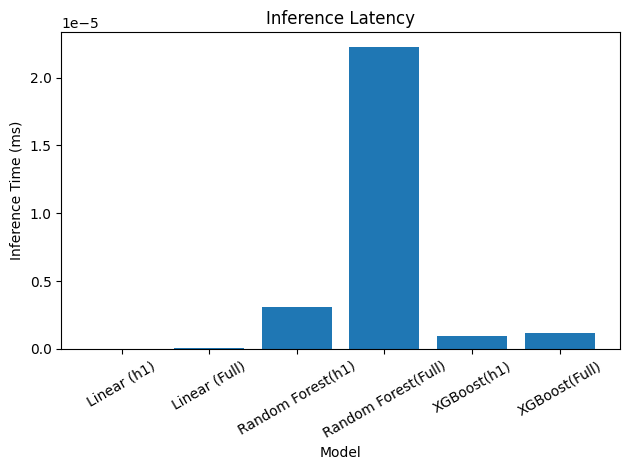

In [24]:
# ===============================
# LATENCY PLOT
# ===============================
import matplotlib.pyplot as plt

plt.figure()

plt.bar(df_results["Model"], df_results["Infer(s)"])

plt.xticks(rotation=30)
plt.xlabel("Model")
plt.ylabel("Inference Time (ms)")
plt.title("Inference Latency")

plt.tight_layout()

plt.savefig("latency_ieee.png", dpi=300)

plt.show()

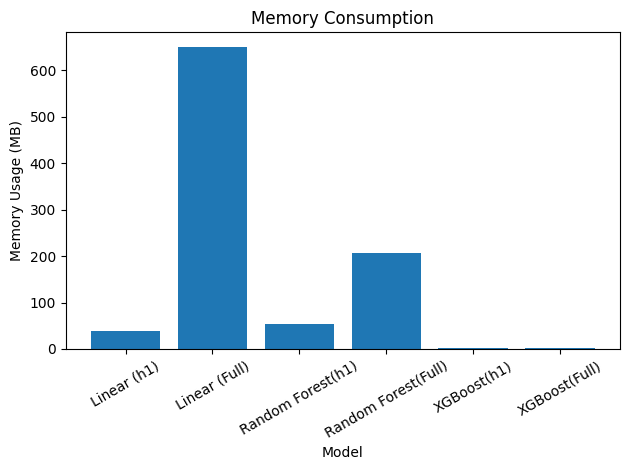

In [25]:
# ===============================
# MEMORY PLOT
# ===============================
import matplotlib.pyplot as plt

plt.figure()

plt.bar(df_results["Model"], df_results["Memory(MB)"])

plt.xticks(rotation=30)
plt.xlabel("Model")
plt.ylabel("Memory Usage (MB)")
plt.title("Memory Consumption")

plt.tight_layout()

plt.savefig("memory_usage.png", dpi=300)

plt.show()

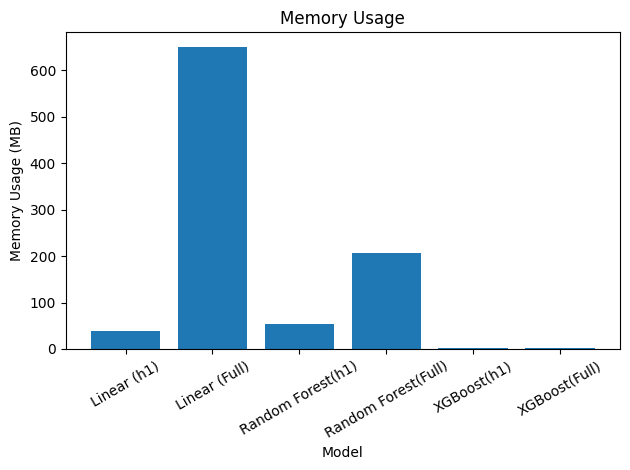

In [26]:
# ===============================
# MEMORY PLOT
# ===============================
import matplotlib.pyplot as plt

plt.figure()

plt.bar(df_results["Model"], df_results["Memory(MB)"])

plt.xticks(rotation=30)
plt.xlabel("Model")
plt.ylabel("Memory Usage (MB)")
plt.title("Memory Usage")

plt.tight_layout()

plt.savefig("memory_usage.png", dpi=300)

plt.show()

In [27]:
# ===============================
# LATEX TABLE
# ===============================
def latex_table(df):

    txt = "\\begin{tabular}{lcccccc}\n\\hline\n"
    txt += "Model & MAE & RMSE & R2 & Train & Infer & Memory \\\\ \n\\hline\n"

    for _, r in df.iterrows():
        txt += (
            f"{r['Model']} & "
            f"{r['MAE']:.3f} & "
            f"{r['RMSE']:.3f} & "
            f"{r['R2']:.4f} & "
            f"{r['Train(s)']:.2f} & "
            f"{r['Infer(s)']:.6f} & "
            f"{r['Memory(MB)']:.2f} \\\\ \n"
        )

    txt += "\\hline\n\\end{tabular}"

    return txt

print(latex_table(df_results))

\begin{tabular}{lcccccc}
\hline
Model & MAE & RMSE & R2 & Train & Infer & Memory \\ 
\hline
Linear (h1) & 1.894 & 22.820 & 0.9883 & 0.06 & 0.000000 & 39.38 \\ 
Linear (Full) & 1.710 & 22.720 & 0.9884 & 3.51 & 0.000000 & 649.68 \\ 
Random Forest(h1) & 1.333 & 23.329 & 0.9878 & 44.64 & 0.000003 & 54.22 \\ 
Random Forest(Full) & 0.917 & 19.170 & 0.9917 & 2370.23 & 0.000022 & 206.79 \\ 
XGBoost(h1) & 2.765 & 30.876 & 0.9786 & 7.11 & 0.000001 & 1.28 \\ 
XGBoost(Full) & 1.191 & 19.744 & 0.9912 & 14.85 & 0.000001 & 1.24 \\ 
\hline
\end{tabular}


In [28]:
def latex_table(df):

    txt = "\\begin{table}[h]\n\\centering\n"
    txt += "\\caption{Performance and latency comparison}\n"
    txt += "\\label{tab:results}\n"
    txt += "\\begin{tabular}{lcccccc}\n\\hline\n"

    txt += "Model & MAE & RMSE & R2 & Train (s) & Infer (ms) & Memory (MB) \\\\ \n\\hline\n"

    for _, r in df.iterrows():
        txt += (
            f"{r['Model']} & "
            f"{r['MAE']:.3f} & "
            f"{r['RMSE']:.3f} & "
            f"{r['R2']:.4f} & "
            f"{r['Train(s)']:.2f} & "
            f"{r['Infer(s)']*1000:.3f} & "
            f"{r['Memory(MB)']:.2f} \\\\ \n"
        )

    txt += "\\hline\n\\end{tabular}\n\\end{table}"

    return txt

print(latex_table(df_results))

\begin{table}[h]
\centering
\caption{Performance and latency comparison}
\label{tab:results}
\begin{tabular}{lcccccc}
\hline
Model & MAE & RMSE & R2 & Train (s) & Infer (ms) & Memory (MB) \\ 
\hline
Linear (h1) & 1.894 & 22.820 & 0.9883 & 0.06 & 0.000 & 39.38 \\ 
Linear (Full) & 1.710 & 22.720 & 0.9884 & 3.51 & 0.000 & 649.68 \\ 
Random Forest(h1) & 1.333 & 23.329 & 0.9878 & 44.64 & 0.003 & 54.22 \\ 
Random Forest(Full) & 0.917 & 19.170 & 0.9917 & 2370.23 & 0.022 & 206.79 \\ 
XGBoost(h1) & 2.765 & 30.876 & 0.9786 & 7.11 & 0.001 & 1.28 \\ 
XGBoost(Full) & 1.191 & 19.744 & 0.9912 & 14.85 & 0.001 & 1.24 \\ 
\hline
\end{tabular}
\end{table}


In [29]:
# ===============================
# LATEX TABLE COM DESTAQUE
# ===============================
def latex_table_highlight(df):

    # Identificar melhores valores
    best_mae = df["MAE"].min()
    best_rmse = df["RMSE"].min()
    best_r2 = df["R2"].max()
    best_infer = df["Infer(s)"].min()
    best_mem = df["Memory(MB)"].min()

    txt = "\\begin{table}[h]\n\\centering\n"
    txt += "\\caption{Performance and latency comparison}\n"
    txt += "\\label{tab:results}\n"
    txt += "\\begin{tabular}{lcccccc}\n\\hline\n"

    txt += "Model & MAE & RMSE & R2 & Train (s) & Infer (ms) & Memory (MB) \\\\ \n\\hline\n"

    for _, r in df.iterrows():

        mae = f"{r['MAE']:.3f}"
        rmse = f"{r['RMSE']:.3f}"
        r2 = f"{r['R2']:.4f}"
        train = f"{r['Train(s)']:.2f}"
        infer = f"{r['Infer(s)']*1000:.3f}"
        mem = f"{r['Memory(MB)']:.2f}"

        # Aplicar negrito nos melhores
        if r["MAE"] == best_mae:
            mae = f"\\textbf{{{mae}}}"
        if r["RMSE"] == best_rmse:
            rmse = f"\\textbf{{{rmse}}}"
        if r["R2"] == best_r2:
            r2 = f"\\textbf{{{r2}}}"
        if r["Infer(s)"] == best_infer:
            infer = f"\\textbf{{{infer}}}"
        if r["Memory(MB)"] == best_mem:
            mem = f"\\textbf{{{mem}}}"

        txt += (
            f"{r['Model']} & {mae} & {rmse} & {r2} & "
            f"{train} & {infer} & {mem} \\\\ \n"
        )

    txt += "\\hline\n\\end{tabular}\n\\end{table}"

    return txt

print(latex_table_highlight(df_results))

\begin{table}[h]
\centering
\caption{Performance and latency comparison}
\label{tab:results}
\begin{tabular}{lcccccc}
\hline
Model & MAE & RMSE & R2 & Train (s) & Infer (ms) & Memory (MB) \\ 
\hline
Linear (h1) & 1.894 & 22.820 & 0.9883 & 0.06 & \textbf{0.000} & 39.38 \\ 
Linear (Full) & 1.710 & 22.720 & 0.9884 & 3.51 & 0.000 & 649.68 \\ 
Random Forest(h1) & 1.333 & 23.329 & 0.9878 & 44.64 & 0.003 & 54.22 \\ 
Random Forest(Full) & \textbf{0.917} & \textbf{19.170} & \textbf{0.9917} & 2370.23 & 0.022 & 206.79 \\ 
XGBoost(h1) & 2.765 & 30.876 & 0.9786 & 7.11 & 0.001 & 1.28 \\ 
XGBoost(Full) & 1.191 & 19.744 & 0.9912 & 14.85 & 0.001 & \textbf{1.24} \\ 
\hline
\end{tabular}
\end{table}
